# **Task-1**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/data.zip

Archive:  /content/drive/MyDrive/data.zip
   creating: faculty_sites/
  inflating: faculty_sites/sites.google.com_view_sharmapuneet.txt  
  inflating: faculty_sites/sites.google.com_view_abhisheksarkar.txt  
  inflating: faculty_sites/home.iitj.ac.in_~goravb_.txt  
  inflating: faculty_sites/3dcomputervision.github.io_.txt  
  inflating: faculty_sites/home.iitj.ac.in_~richa_.txt  
  inflating: faculty_sites/sites.google.com_site_dipsankarban_.txt  
  inflating: faculty_sites/anandmishra22.github.io_.txt  
  inflating: faculty_sites/sites.google.com_view_angshumanpaul_research.txt  
  inflating: faculty_sites/sites.google.com_iitj.ac.in_rims_rims-head.txt  
  inflating: faculty_sites/home.iitj.ac.in_~sy_.txt  
  inflating: faculty_sites/sites.google.com_view_angshumanpaul_.txt  
  inflating: faculty_sites/sites.google.com_view_nil-kamal-hazra.txt  
  inflating: faculty_sites/sites.google.com_view_lawqueenkanesh_.txt  
   creating: iitj_pages/
  inflating: iitj_pages/www.iitj.ac.in_compu

Dataset Preparation

In [ ]:
import glob, re, os, math, random, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

stopwords = {
    "is","are","was","were","be","been","being","have","has","had","do","does",
    "this","it","its","by","from","as","into","through","during","before",
    "both","each","more","most","other","some","such","no","not","only","own",
    "did","will","would","could","should","may","might","shall","can","that",
    "the","a","an","and","or","but","in","on","at","to","for","of","with",
    "his","her","their","our","up","if","also","any","these","those","what",
    "after","above","below","between","out","off","over","under","again",
    "further","then","once","here","there","when","where","why","how","all",
    "he","she","they","we","you","i","my","your", "iit","jodhpur","iitj",
    "same","so","than","too","very","just","about","which","who","whom","s"
}

# Loading data
all_text = ""
doc_count = 0
folders = ["faculty_sites", "iitj_pages", "pdf_data"]

for folder in folders:
    for filename in os.listdir(folder):
        if filename.endswith(".txt"):
            path = os.path.join(folder, filename)
            with open(path, "r") as f:
                all_text += f.read() + " "
                doc_count += 1

print(f"Total documents : {doc_count}")

#splitiing into sentences
raw_sentences = re.split(r"[.!?]", all_text)

sentences = []


for sentence in raw_sentences:
  # cleaning
  sentence = sentence.lower()
  sentence = re.sub(r"http\S+", "", sentence)   # remove urls
  sentence = re.sub(r"[^a-z\s]", " ", sentence)  # removing elements that are not alphabets and spaces

  words = sentence.split()

  clean_words = []
  for word in words:
      if word not in stopwords and len(word) > 1:
          clean_words.append(word)

  if len(clean_words) > 0:
      sentences.append(clean_words)


tokens  = [t for s in sentences for t in s]       # flat list for stats

total_tokens = len(tokens)
vocab = set(tokens)
vocab_size = len(vocab)

print(f"Total tokens    : {total_tokens:,}")
print(f"Vocabulary size : {vocab_size:,}")
print(f"Total sentences : {len(sentences):,}")

# saving clean corpus
with open("final_corpus.txt", "w") as f:
    for sent in sentences:
        f.write(" ".join(sent) + "\n")

print("\nCorpus saved to final_corpus.txt")

Total documents : 35
Total tokens    : 60,527
Vocabulary size : 6,882
Total sentences : 7,663

Corpus saved to final_corpus.txt


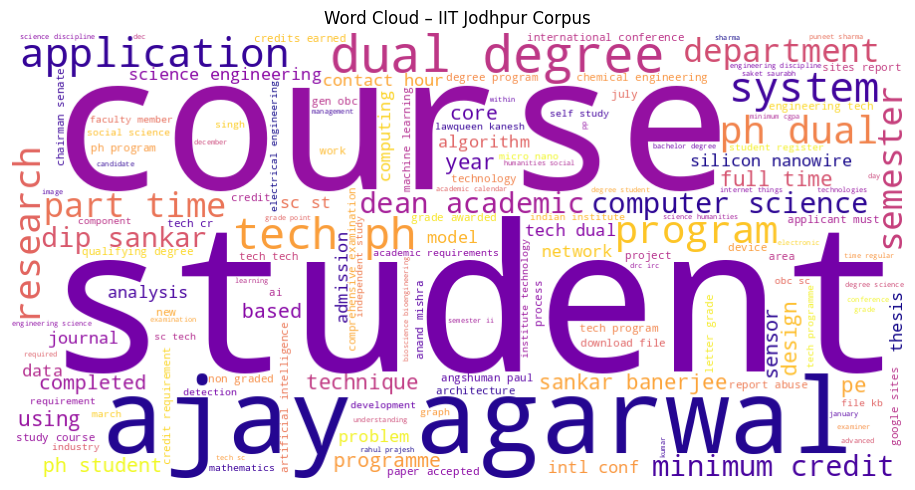

In [ ]:
# word cloud
wc = WordCloud(width=900, height=450, background_color="white",
               max_words=150, colormap="plasma")
wc.generate(" ".join(tokens))
plt.figure(figsize=(12, 5))
plt.imshow(wc); plt.axis("off"); plt.title("Word Cloud – IIT Jodhpur Corpus")
plt.tight_layout(); plt.savefig("wordcloud.png", dpi=150); plt.show()


In [ ]:
print(vocab)

{'tung', 'textual', 'combinatorics', 'sensitive', 'aaai', 'instructions', 'ad', 'requisite', 'cryptographic', 'fpga', 'hfet', 'greece', 'platform', 'biconnected', 'opted', 'visits', 'scopus', 'presenting', 'sustenance', 'teo', 'evolving', 'permits', 'ultrasmall', 'directed', 'guide', 'integrative', 'enhancing', 'examples', 'chaturvedi', 'central', 'reported', 'held', 'laplace', 'prospects', 'color', 'decision', 'se', 'synthesis', 'review', 'attending', 'biomarkers', 'marks', 'big', 'mts', 'via', 'insights', 'september', 'suman', 'mapan', 'celebration', 'dgx', 'interested', 'panolan', 'les', 'themake', 'vikas', 'spvm', 'assistance', 'habib', 'tale', 'dualdegreeprogramwillbeapplicabletoallsuchstudents', 'extra', 'corporation', 'visualization', 'graphene', 'vikash', 'outreach', 'tool', 'leave', 'acetylene', 'industry', 'anomaly', 'atmanirbhar', 'execution', 'fulfilled', 'efficiency', 'opportunity', 'coding', 'internationally', 'consequent', 'degreemtech', 'em', 'brns', 'ormoreaftercomplet

In [ ]:
from collections import Counter

word_counts = Counter(tokens)

top10 = word_counts.most_common(10)

for word, freq in top10:
    print(f"{word}, {freq}")

tech, 752
student, 631
engineering, 501
course, 498
agarwal, 465
ph, 436
degree, 408
program, 400
semester, 398
students, 391


# **Task-2**

In [ ]:

# Step-1 converting word to numbers
# for that, first assigning indices to each word

def build_vocab(sentences, min_count=2):
  # counting frequencies
  freq_dict = {}

  for sentence in sentences:
      for word in sentence:
          if word in freq_dict:
              freq_dict[word] += 1
          else:
              freq_dict[word] = 1

  # removing rare words as generally of no use!
  vocab_words = []

  for word in freq_dict:
      if freq_dict[word] >= min_count:
          vocab_words.append(word)

  # creating word → index mapping
  word2idx = {}
  idx2word = {}

  index = 0
  for word in vocab_words:
      word2idx[word] = index
      idx2word[index] = word
      index += 1

  # frequency array
  freq_list = []

  for word in vocab_words:
      freq_list.append(freq_dict[word])

  freq_arr = np.array(freq_list, dtype=np.float32)

  return word2idx, idx2word, freq_arr


word2idx, idx2word, freq_arr = build_vocab(sentences, min_count=2)
V = len(word2idx)          # final vocab size after min_count filter
print(f"\nVocab after min_count=2 filter: {V:,}")

# converting sentences word by word into list of numbers
encoded_sentences = []

for sentence in sentences:
  encoded_sentence = []
  for word in sentence:
      if word in word2idx:
          encoded_sentence.append(word2idx[word])

  if len(encoded_sentence) > 0:
      encoded_sentences.append(encoded_sentence)
# eg [He,likes,football]->{23,7,889}




# Negative Sampling Table
def building_neg_table(freq_arr,table_size=1000000):
  f_table = []
  for f in freq_arr:
      f_table.append(f ** 0.75)
  total = sum(f_table)

  probs = []
  for val in f_table:
      probs.append(val / total)
  table   = np.zeros(table_size, dtype=np.int32)

  '''
  what we are trying to do is, let's suppose counts of a,b,c-> [2,5,3]
  instead of finding prob by counting, we make a table and then randomly sample values from tehre
  table [ a a b b b b b c c c]
  '''
  i=0
  for word_idx, p in enumerate(probs):
      count = int(p * table_size)
      table[i: i + count] = word_idx
      i += count

  if i < table_size:
        table[i:] = len(probs) - 1
  return table


neg_table = building_neg_table(freq_arr)


def get_negative_samples(t, k, neg_table):
  neg = []

  while len(neg) < k:
      idx = neg_table[np.random.randint(0, len(neg_table))]

        # any word except the curr word
      if idx != t:
          neg.append(idx)

  return neg



def sigmoid(x):
  # avoids overflow when x is -ve
  return np.where(x >= 0,
                  1 / (1 + np.exp(-x)),
                  np.exp(x) / (1 + np.exp(x)))


Vocab after min_count=2 filter: 4,400


CBOW

In [ ]:
class CBOW:
  '''
  1. take context window → get embeds from W_in → average them to form h
  2. then find the dot product of h with output embeddings (W_out) of target and negative words to get scores.
  3. then apply sigmoid to convert scores into prob and train the model to assign high prob to the correct word.
  '''
  def __init__(self, vocab_size, embed_dim=100):
    self.V    = vocab_size
    self.D    = embed_dim
    # randomly initilaising Win and Wout size VxD
    self.Win  = (np.random.rand(vocab_size, embed_dim) - 0.5) / embed_dim
    self.Wout = (np.random.rand(vocab_size, embed_dim) - 0.5) / embed_dim

  def train_pair(self, context_ids, target_id, neg_ids, lr):
    if not context_ids:
        return 0.0

    #find the avg of context embeddings
    context_vectors = self.Win[context_ids]
    h = np.mean(context_vectors, axis=0)   # shape (D,)

    #labels mean 1 for actual target and 0 for neg samples
    words = [target_id] + list(neg_ids)
    labels = np.array([1] + [0]*len(neg_ids), dtype=np.float32)

    #compute scores using dot product with Wout and convet to prob using sigmoid
    scores = []
    for w in words:
        score = np.dot(self.Wout[w], h)
        scores.append(score)

    scores = np.array(scores)
    probs = sigmoid(scores)

    #compute loss(cross-entropy)
    loss = -np.sum(labels * np.log(probs + 1e-10) + (1 - labels) * np.log(1 - probs + 1e-10))
    err = probs - labels

    #gradient for context vector
    grad_h = np.zeros(h.shape)
    for i, w in enumerate(words):
        grad_h += err[i] * self.Wout[w]

    #update W_out
    for i, w in enumerate(words):
        self.Wout[w] -= lr * err[i] * h

    #update W_in [ divide grad among all the context words]
    grad_context = grad_h / len(context_ids)
    for c in context_ids:
        self.Win[c] -= lr * grad_context

    return float(loss)


  def train(self, encoded_sents, neg_table, window=2,neg_k=5, epochs=5, lr=0.025):

    print(f"\n{'-'*60}")
    print(f" CBOW  |  dim={self.D}  win={window}  neg={neg_k}  ep={epochs}")
    print(f"{'-'*60}")

    for epoch in range(epochs):
        total_loss, pairs = 0.0, 0

        # Learning rate linear decay
        curr_lr = lr * (1 - epoch / (epochs + 1))
        curr_lr = max(curr_lr, lr * 0.0001)
        random.shuffle(encoded_sents)

        for sentence in encoded_sents:
            for i, target in enumerate(sentence): #considering every word of sentence as a target
              context=[]

              for j in range(max(0, i-window),min(len(sentence), i+window+1)):
                if j==i: #dont include the target word in context
                  continue
                context.append(sentence[j])

              if not context:
                  continue

              negs = get_negative_samples(target, neg_k, neg_table) #finding k-neg samples correspondng to target
              total_loss += self.train_pair(context, target, negs, curr_lr)
              pairs += 1

        print(f"  Epoch {epoch+1}/{epochs}  "
              f"loss={total_loss/max(pairs,1):.4f}  "
              f"lr={curr_lr:.5f}  ")

    print(" CBOW training complete.")
    return self


  @property
  def embeddings(self):
    return self.Win.copy()

SkipGram with Negative Sampling

In [ ]:
class SkipGram:
  '''
  1. take centre word → get embedding from W_in → this becomes h
  2. then find the dot product of h with output embeddings (W_out) of context and negative words to get scores.
  3. then apply sigmoid to convert scores into prob and train the model to assign high prob to correct context words.
  '''
  def __init__(self, vocab_size, embed_dim=100):
    self.V    = vocab_size
    self.D    = embed_dim
    # randomly initilaising Win and Wout size VxD
    self.Win  = (np.random.rand(vocab_size, embed_dim) - 0.5) / embed_dim
    self.Wout = (np.random.rand(vocab_size, embed_dim) - 0.5) / embed_dim

  def train_pair(self, centre_id, context_id, neg_ids, lr):
    h = self.Win[centre_id]   #the centre word

    #context word and neg samples
    words  = [context_id] + list(neg_ids)
    labels = np.array([1] + [0] * len(neg_ids), dtype=np.float32)

    #compute scores using dot product
    scores = []
    for w in words:
        score = np.dot(self.Wout[w], h)
        scores.append(score)

    scores = np.array(scores)
    probs  = sigmoid(scores)

    # loss
    loss = -np.sum(labels * np.log(probs + 1e-10) + (1 - labels) * np.log(1 - probs + 1e-10))
    err = probs - labels

    # gradient for centre word vector
    grad_h = np.zeros(h.shape)
    for i, w in enumerate(words):
        grad_h += err[i] * self.Wout[w]

    # update Wout
    for i, w in enumerate(words):
        self.Wout[w] -= lr * err[i] * h

    # update Win (only centre word)
    self.Win[centre_id] -= lr * grad_h

    return float(loss)

  def train(self, encoded_sents, neg_table, window=2,
            neg_k=5, epochs=5, lr=0.025):

    print(f"\n{'='*55}")
    print(f" SGNS  |  dim={self.D}  win={window}  neg={neg_k}  ep={epochs}")
    print(f"{'='*55}")

    for epoch in range(epochs):
        total_loss, pairs = 0.0, 0
        cur_lr = lr * (1 - epoch / (epochs + 1))
        cur_lr = max(cur_lr, lr * 0.0001)
        random.shuffle(encoded_sents)

        for sentence in encoded_sents:
            for i, centre in enumerate(sentence):
                for j in range(max(0, i-window),
                                min(len(sentence), i+window+1)):
                    if j == i:
                        continue

                    negs = get_negative_samples(centre, neg_k, neg_table)
                    total_loss += self.train_pair(
                        centre, sentence[j], negs, cur_lr)
                    pairs += 1

        print(f"  Epoch {epoch+1}/{epochs}  "
              f"loss={total_loss/max(pairs,1):.4f}  "
              f"lr={cur_lr:.5f}  ")

    print("Skip-gram training complete.")
    return self

  @property
  def embeddings(self):
    return self.Win.copy()


In [ ]:
# Hyperparameter Tuning
# Each entry: (embed_dim, window, neg_k, epochs)
CONFIGS = [
    (50,  2, 5, 5),
    (100, 4, 5, 5),
    (100, 2, 10, 5),
]

results = {}   # key → (model_obj, config_tuple)

for cfg in CONFIGS:
    dim, win, neg, ep = cfg
    tag = f"d{dim}_w{win}_n{neg}"

    cbow = CBOW(V, embed_dim=dim)
    cbow.train(encoded_sentences, neg_table,
               window=win, neg_k=neg, epochs=ep)
    results[f"cbow_{tag}"] = (cbow, cfg)

    sg = SkipGram(V, embed_dim=dim)
    sg.train(encoded_sentences, neg_table,
             window=win, neg_k=neg, epochs=ep)
    results[f"sgns_{tag}"] = (sg, cfg)

# Pick best models for Tasks 3 & 4 (100-d, window=4)
best_cbow = results["cbow_d100_w4_n5"][0]
best_sgns = results["sgns_d100_w4_n5"][0]



------------------------------------------------------------
 CBOW  |  dim=50  win=2  neg=5  ep=5
------------------------------------------------------------
  Epoch 1/5  loss=4.1588  lr=0.02500  
  Epoch 2/5  loss=4.1529  lr=0.02083  
  Epoch 3/5  loss=4.0326  lr=0.01667  
  Epoch 4/5  loss=3.6769  lr=0.01250  
  Epoch 5/5  loss=3.3883  lr=0.00833  
 CBOW training complete.

 SGNS  |  dim=50  win=2  neg=5  ep=5
  Epoch 1/5  loss=3.9814  lr=0.02500  
  Epoch 2/5  loss=2.9215  lr=0.02083  
  Epoch 3/5  loss=2.4116  lr=0.01667  
  Epoch 4/5  loss=2.1793  lr=0.01250  
  Epoch 5/5  loss=2.0541  lr=0.00833  
Skip-gram training complete.

------------------------------------------------------------
 CBOW  |  dim=100  win=4  neg=5  ep=5
------------------------------------------------------------
  Epoch 1/5  loss=4.1588  lr=0.02500  
  Epoch 2/5  loss=4.1558  lr=0.02083  
  Epoch 3/5  loss=4.0776  lr=0.01667  
  Epoch 4/5  loss=3.7535  lr=0.01250  
  Epoch 5/5  loss=3.4435  lr=0.00833  
 C

In [ ]:
# training one model with 300 dimensions (for report )

dim, win, neg, ep = 300, 4, 5, 5

cbow_300 = CBOW(V, embed_dim=dim)
cbow_300.train(encoded_sentences, neg_table,
               window=win, neg_k=neg, epochs=ep)

print("CBOW 300-dim training complete")


------------------------------------------------------------
 CBOW  |  dim=300  win=4  neg=5  ep=5
------------------------------------------------------------
  Epoch 1/5  loss=4.1589  lr=0.02500  
  Epoch 2/5  loss=4.1580  lr=0.02083  
  Epoch 3/5  loss=4.1279  lr=0.01667  
  Epoch 4/5  loss=3.9160  lr=0.01250  
  Epoch 5/5  loss=3.6102  lr=0.00833  
 CBOW training complete.
CBOW 300-dim training complete


In [ ]:
word = "btech"

idx = word2idx[word]          # get index
vector = cbow_300.embeddings[idx]   # get embedding

print(f"{word} - {', '.join([str(round(x,4)) for x in vector])}")
print("Length:", len(vector))

btech - 0.013, 0.018, 0.0036, -0.0031, -0.0009, 0.0233, 0.0124, -0.0149, 0.0008, -0.0161, -0.0117, 0.0102, -0.0007, 0.0078, 0.0005, 0.0028, -0.0049, -0.0002, -0.005, -0.0082, -0.0162, -0.0007, -0.0102, -0.0054, 0.0018, 0.0072, -0.0157, -0.0126, -0.0012, -0.0087, -0.0063, -0.0131, 0.0068, 0.0121, 0.0086, 0.0116, 0.0047, -0.0137, 0.0206, 0.003, 0.0004, -0.0155, 0.0025, 0.0087, -0.0027, 0.0038, -0.0, -0.0176, 0.0102, -0.0066, -0.0144, 0.0081, -0.0058, -0.0036, 0.0051, -0.0013, 0.002, -0.0054, -0.006, 0.0095, -0.0022, -0.0068, -0.0129, 0.023, 0.004, 0.0153, 0.0081, -0.0054, -0.0123, 0.0059, -0.0068, -0.0054, -0.0046, 0.0208, -0.0041, 0.0077, 0.0021, 0.0096, 0.0129, -0.0036, -0.0094, 0.0019, -0.0035, 0.0021, 0.0011, 0.0136, 0.0092, -0.009, 0.0093, -0.0043, 0.0066, 0.0123, 0.0045, 0.0097, 0.0107, 0.0022, -0.0037, -0.0059, -0.0055, -0.0025, 0.0036, -0.0098, -0.0064, -0.0039, -0.0005, -0.0049, -0.0141, 0.0033, 0.0012, 0.0005, 0.007, -0.0033, 0.0035, -0.0048, -0.0149, 0.0015, -0.009, 0.0186, 0.

# **Task-3**

Top-5 Nearest Neighbours

In [ ]:
#Task-3

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

def top_k_neighbors(word, emb, word2idx, idx2word, k=5):
    if word not in word2idx:
        return []

    vec = emb[word2idx[word]]
    scores = []

    for i in range(len(emb)):
        sim = cosine_sim(vec, emb[i])
        scores.append((idx2word[i], sim))

    scores = [s for s in scores if s[0] != word]
    scores.sort(key=lambda x: x[1], reverse=True) # sorting

     # print nicely (4 decimal places)
    for w, s in scores[:k]:
        print(f"{w}({s:.4f})", end=", ")

    print()  # new line

words =  ["research", "student", "phd", "exam", "department"]

for w in words:
    print(f"\nWord: {w}")
    print("CBOW:")
    top_k_neighbors(w, best_cbow.Win, word2idx, idx2word)
    print("SGNS:")
    top_k_neighbors(w, best_sgns.Win, word2idx, idx2word)


Word: research
CBOW:
learning(0.9997), india(0.9997), senate(0.9996), detection(0.9996), evaluation(0.9996), 
SGNS:
proposal(0.7232), interests(0.7137), representative(0.7113), areas(0.6752), excellence(0.6723), 

Word: student
CBOW:
registration(0.9996), completed(0.9995), academic(0.9994), students(0.9993), semester(0.9992), 
SGNS:
visiting(0.7585), disciplinary(0.7553), falls(0.7552), carry(0.7475), purpose(0.7397), 

Word: phd
CBOW:
students(0.9994), must(0.9993), programme(0.9992), institute(0.9990), system(0.9990), 
SGNS:
pursuing(0.8516), mtech(0.8446), successfully(0.8112), interested(0.8002), coursework(0.7896), 

Word: exam
CBOW:
graduation(0.9711), industry(0.9707), paul(0.9707), request(0.9706), must(0.9704), 
SGNS:
intimated(0.9736), syllabus(0.9618), scheduled(0.9592), separate(0.9538), appointment(0.9525), 

Word: department
CBOW:
institute(0.9996), core(0.9996), medical(0.9995), technology(0.9995), data(0.9995), 
SGNS:
head(0.8558), mention(0.8110), moderation(0.8078),

Analogy Experiment

In [ ]:
def analogy(a, b, c, emb_matrix, word2idx, idx2word, k=5):
    """
    a : b :: c : ?
    target vector = emb[b] - emb[a] + emb[c]
    """
    for w in (a, b, c):
        if w not in word2idx:
            return [(f"('{w}' OOV)", 0.0)]

    vec = (emb_matrix[word2idx[b]]
           - emb_matrix[word2idx[a]]
           + emb_matrix[word2idx[c]])

    norms   = np.linalg.norm(emb_matrix, axis=1, keepdims=True) + 1e-10
    vec_n   = np.linalg.norm(vec) + 1e-10
    sims    = (emb_matrix @ vec) / (norms.squeeze() * vec_n)

    # mask query words
    for w in (a, b, c):
        sims[word2idx[w]] = -1

    top_idx = np.argsort(sims)[::-1][:k]
    return [(idx2word[i], float(sims[i])) for i in top_idx]


ANALOGIES = [
    ("ug", "btech", "pg"),         # ug:btech :: pg:?
    ("professor", "research", "student"),   # professor:research :: student:?
    ("undergraduate", "course", "phd"),     # undergraduate:course :: phd:?
    ("bachelor","undergraduate","master")
]

print("\n" + "="*60)
print("  ANALOGY EXPERIMENTS   (a : b :: c : ?)")
print("="*60)

for a, b, c in ANALOGIES:
    print(f"\n  {a} : {b} :: {c} : ?")
    for model_name, model_obj in [("CBOW", best_cbow), ("SGNS", best_sgns)]:
        results_analogy = analogy(a, b, c,
                                  model_obj.embeddings, word2idx, idx2word)
        res_str = ", ".join(f"{w}({s:.3f})" for w, s in results_analogy[:5])
        print(f"    {model_name:4s}: {res_str}")



  ANALOGY EXPERIMENTS   (a : b :: c : ?)

  ug : btech :: pg : ?
    CBOW: bog(0.951), sets(0.948), probability(0.947), specialization(0.947), bioengineering(0.947)
    SGNS: mtech(0.920), mba(0.913), regulations(0.911), governed(0.910), file(0.904)

  professor : research :: student : ?
    CBOW: registration(1.000), thesis(1.000), students(1.000), per(1.000), examination(1.000)
    SGNS: carry(0.666), visiting(0.597), disciplinary(0.572), purpose(0.563), work(0.562)

  undergraduate : course :: phd : ?
    CBOW: study(0.999), requirements(0.999), academic(0.999), number(0.999), grade(0.999)
    SGNS: ca(0.703), engagement(0.697), practicals(0.696), withdrawing(0.694), instructor(0.691)

  bachelor : undergraduate :: master : ?
    CBOW: department(0.998), mathematics(0.998), data(0.998), software(0.998), design(0.998)
    SGNS: postgraduate(0.897), doctoral(0.854), en(0.845), enable(0.842), cse(0.831)


# **Task-4**

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def plot_embeddings(words, emb, word2idx, title="Embeddings"):

    vectors = []
    labels = []

    # collect vectors
    for w in words:
        if w in word2idx:
            vectors.append(emb[word2idx[w]])
            labels.append(w)

    vectors = np.array(vectors)

    # apply PCA → 2D
    pca = PCA(n_components=2)
    coords = pca.fit_transform(vectors)

    # plot
    plt.figure(figsize=(8,6))
    for i, word in enumerate(labels):
        x, y = coords[i]
        plt.scatter(x, y)
        plt.text(x, y, word)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

In [ ]:
words = [
    # students / academics
    "student", "students", "course", "semester", "exam", "cgpa",

    # degrees
    "ug", "btech", "pg", "mtech", "phd",

    # research
    "research", "project", "thesis", "publication",

    # roles
    "professor", "faculty", "head", "department",

    # actions / context
    "admission", "enrolled", "registration", "attendance"
]

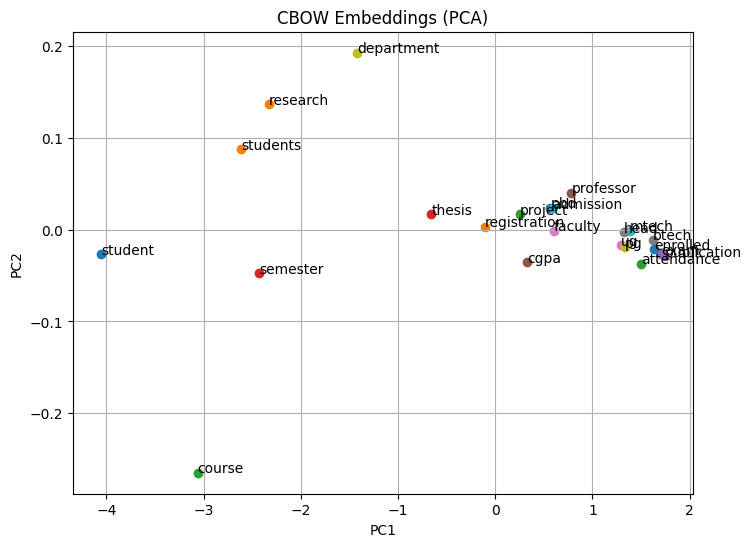

In [ ]:
plot_embeddings(words, best_cbow.Win, word2idx, "CBOW Embeddings (PCA)")


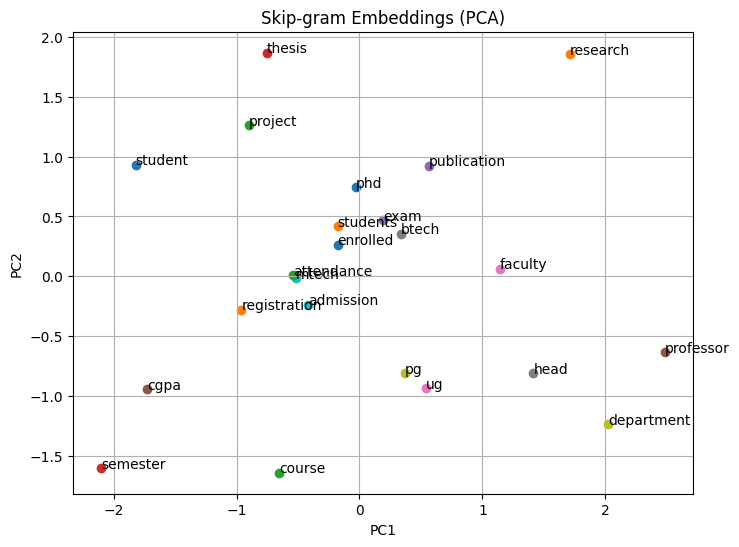

In [ ]:
plot_embeddings(words, best_sgns.Win, word2idx, "Skip-gram Embeddings (PCA)")

In [ ]:
words = [
    "student", "phd", "research", "exam",
    "professor", "faculty", "course",
    "ug", "btech", "pg", "mtech"
]

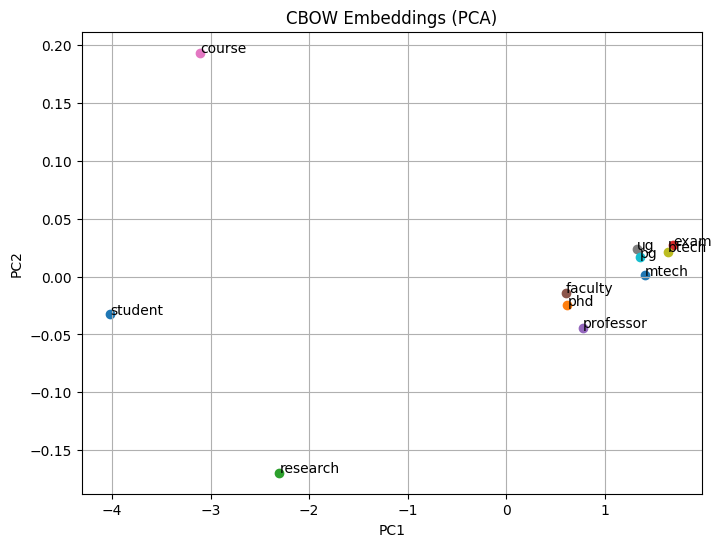

In [ ]:
plot_embeddings(words, best_cbow.Win, word2idx, "CBOW Embeddings (PCA)")


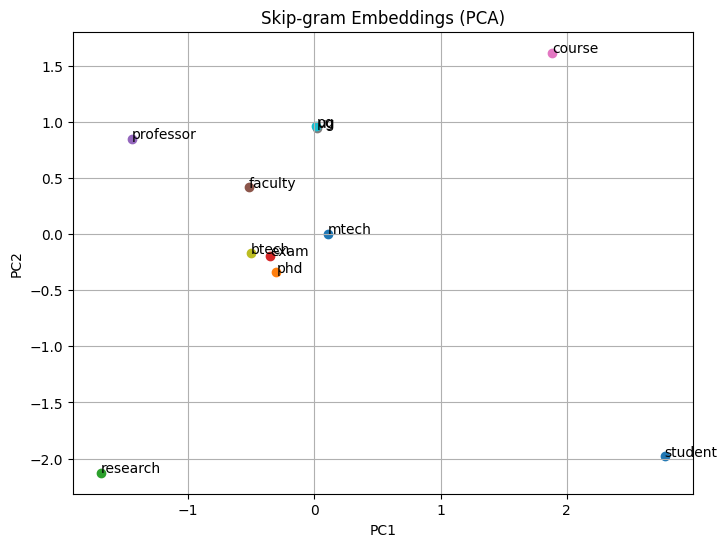

In [ ]:
plot_embeddings(words, best_sgns.Win, word2idx, "Skip-gram Embeddings (PCA)")